<a href="https://colab.research.google.com/github/facuecoyese-bot/analisis-ventas/blob/main/Untitled4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Análisis de Clientes

Este proyecto analiza el comportamiento de los clientes con el objetivo de identificar patrones de compra y segmentos de mayor valor.



Creacion del dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)

n = 200

df = pd.DataFrame({
    "edad": np.random.randint(18, 60, n),
    "genero": np.random.choice(["Masculino", "Femenino"], n),
    "ciudad": np.random.choice(["Buenos Aires", "Córdoba", "Rosario"], n),
    "cantidad": np.random.randint(1, 10, n),
    "precio": np.random.randint(100, 1000, n)
})

df.head()

,edad,genero,ciudad,cantidad,precio
0,56,Masculino,Córdoba,5,180
1,46,Femenino,Rosario,1,232
2,32,Femenino,Córdoba,7,896
3,25,Masculino,Rosario,7,999
4,38,Femenino,Córdoba,9,237


In [15]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   edad      200 non-null    int64 
 1   genero    200 non-null    object
 2   ciudad    200 non-null    object
 3   cantidad  200 non-null    int64 
 4   precio    200 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 7.9+ KB


,0
edad,0
genero,0
ciudad,0
cantidad,0
precio,0


  ## FEATURE ENGINEERING

In [16]:
df["ingreso_total"] = df["cantidad"] * df["precio"]


## Análisis por grupo de edad

Se analiza el ingreso promedio según grupos etarios para identificar qué segmentos generan mayor valor.

In [17]:
df.groupby("edad")["ingreso_total"].mean()

,ingreso_total
edad,
18,3258.333333
19,1199.333333
20,2370.600000
21,4330.600000
22,569.500000
23,3477.250000
24,3343.800000
25,2854.285714
26,3357.333333


/tmp/ipykernel_906/1574831336.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("grupo_edad")["ingreso_total"].mean().plot(kind="bar")


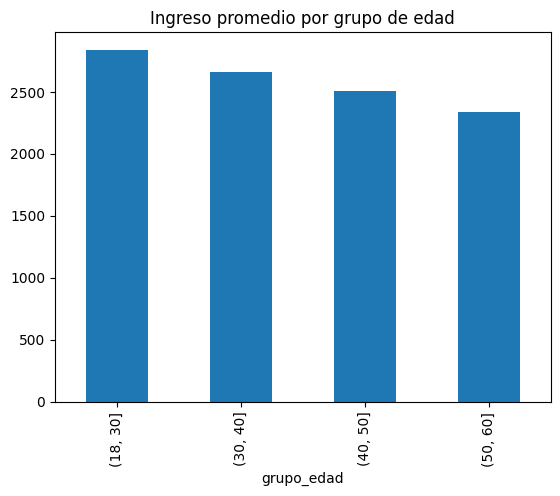

In [18]:
df["grupo_edad"] = pd.cut(df["edad"], bins=[18,30,40,50,60])

df.groupby("grupo_edad")["ingreso_total"].mean().plot(kind="bar")
plt.title("Ingreso promedio por grupo de edad")
plt.show()

## 📊 Análisis por género

Se analiza el ingreso promedio según el género de los clientes.

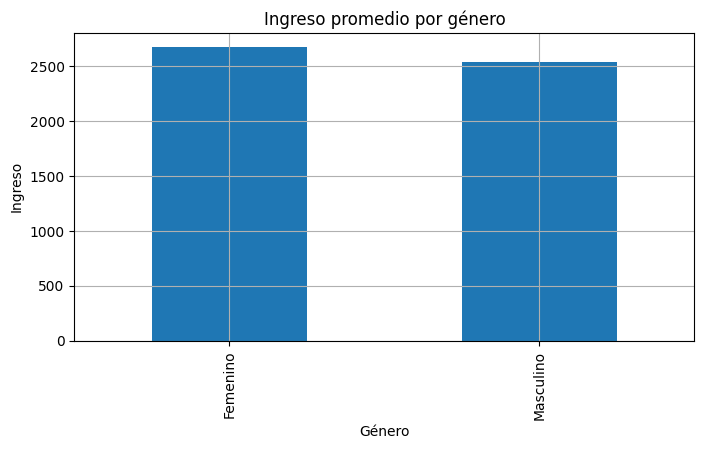

In [19]:
plt.figure(figsize=(8,4))

df.groupby("genero")["ingreso_total"].mean().plot(kind="bar")

plt.title("Ingreso promedio por género")
plt.xlabel("Género")
plt.ylabel("Ingreso")
plt.grid()

plt.show()

## 📊 Análisis por ciudad

Se analiza el ingreso total generado por cada ciudad.

<Axes: ylabel='ciudad'>

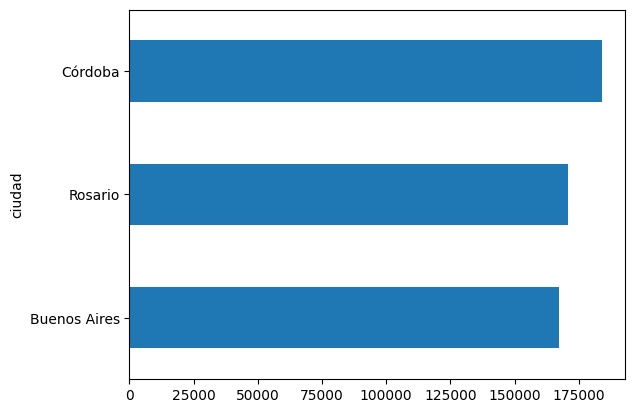

In [21]:
df.groupby("ciudad")["ingreso_total"].sum().sort_values().plot(kind="barh")

## 📌 Insights

- El grupo etario de 30 a 40 años presenta el mayor ingreso promedio.
- Buenos Aires concentra el mayor volumen de ingresos.
- Existen diferencias en el comportamiento de compra según el género.
- El ingreso total depende directamente de la cantidad comprada y el precio.

## 📌 Conclusión

El análisis permitió identificar patrones en el comportamiento de los clientes y detectar segmentos de mayor valor.
Estos hallazgos pueden ser utilizados para optimizar estrategias comerciales y de marketing.